# EDA - Phishing Dataset

- This notebook explores the data of Phishing Dataset from kaggle to find out which features has the highest correlation to `status`
- Dataset: https://www.kaggle.com/datasets/shashwatwork/web-page-phishing-detection-dataset

**Problem Definition:** What problem are we trying to solve?
- Predicting whether a URL is phishing or legitimate
- **Supervised Learning:** Classification (binary)

**Data:** What kind of data do we have?
- **Structured & Static:** all the samples are in similar format and doesn't change over time 

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Data

In [11]:
df = pd.read_csv('../data/dataset_phishing.csv')

In [12]:
df.head()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [13]:
df.shape

(11430, 89)

In [14]:
df.dtypes

url                  str
length_url         int64
length_hostname    int64
ip                 int64
nb_dots            int64
                   ...  
web_traffic        int64
dns_record         int64
google_index       int64
page_rank          int64
status               str
Length: 89, dtype: object

## 2. Class balance

In [15]:
print(df['status'].value_counts())
print(df['status'].value_counts(normalize=True))

status
legitimate    5715
phishing      5715
Name: count, dtype: int64
status
legitimate    0.5
phishing      0.5
Name: proportion, dtype: float64


**Finding:** `legitimate` and `phishing` counts are 50/50 balanced.

## 3. Missing values

In [16]:
df.isnull().sum()

url                0
length_url         0
length_hostname    0
ip                 0
nb_dots            0
                  ..
web_traffic        0
dns_record         0
google_index       0
page_rank          0
status             0
Length: 89, dtype: int64

**Finding:** none `NULL` values

## 4. Drop useless columns

In [18]:
print(df[['ratio_nullHyperlinks', 'ratio_intRedirection', 
          'ratio_intErrors', 'submit_email', 'sfh']].describe())

       ratio_nullHyperlinks  ratio_intRedirection  ratio_intErrors  \
count               11430.0               11430.0          11430.0   
mean                    0.0                   0.0              0.0   
std                     0.0                   0.0              0.0   
min                     0.0                   0.0              0.0   
25%                     0.0                   0.0              0.0   
50%                     0.0                   0.0              0.0   
75%                     0.0                   0.0              0.0   
max                     0.0                   0.0              0.0   

       submit_email      sfh  
count       11430.0  11430.0  
mean            0.0      0.0  
std             0.0      0.0  
min             0.0      0.0  
25%             0.0      0.0  
50%             0.0      0.0  
75%             0.0      0.0  
max             0.0      0.0  


All zeros. These columns are completely useless.

In [19]:
# Drop known zero-variance columns
zero_var_cols = ['ratio_nullHyperlinks', 'ratio_intRedirection',
                 'ratio_intErrors', 'submit_email', 'sfh']
df = df.drop(columns=zero_var_cols)

# Drop any remaining zero-variance columns automatically
zero_var = [col for col in df.columns if df[col].nunique() == 1]
print('Additional zero-variance columns found:', zero_var)
df = df.drop(columns=zero_var)

print(f'Remaining columns: {df.shape[1]}')

Additional zero-variance columns found: ['nb_or']
Remaining columns: 83


**Finding:** 6 zero variance columns removed. All values were 0 across all 11,430 rows, meaning they carry no predictive information.

## 5. Correlation Analysis

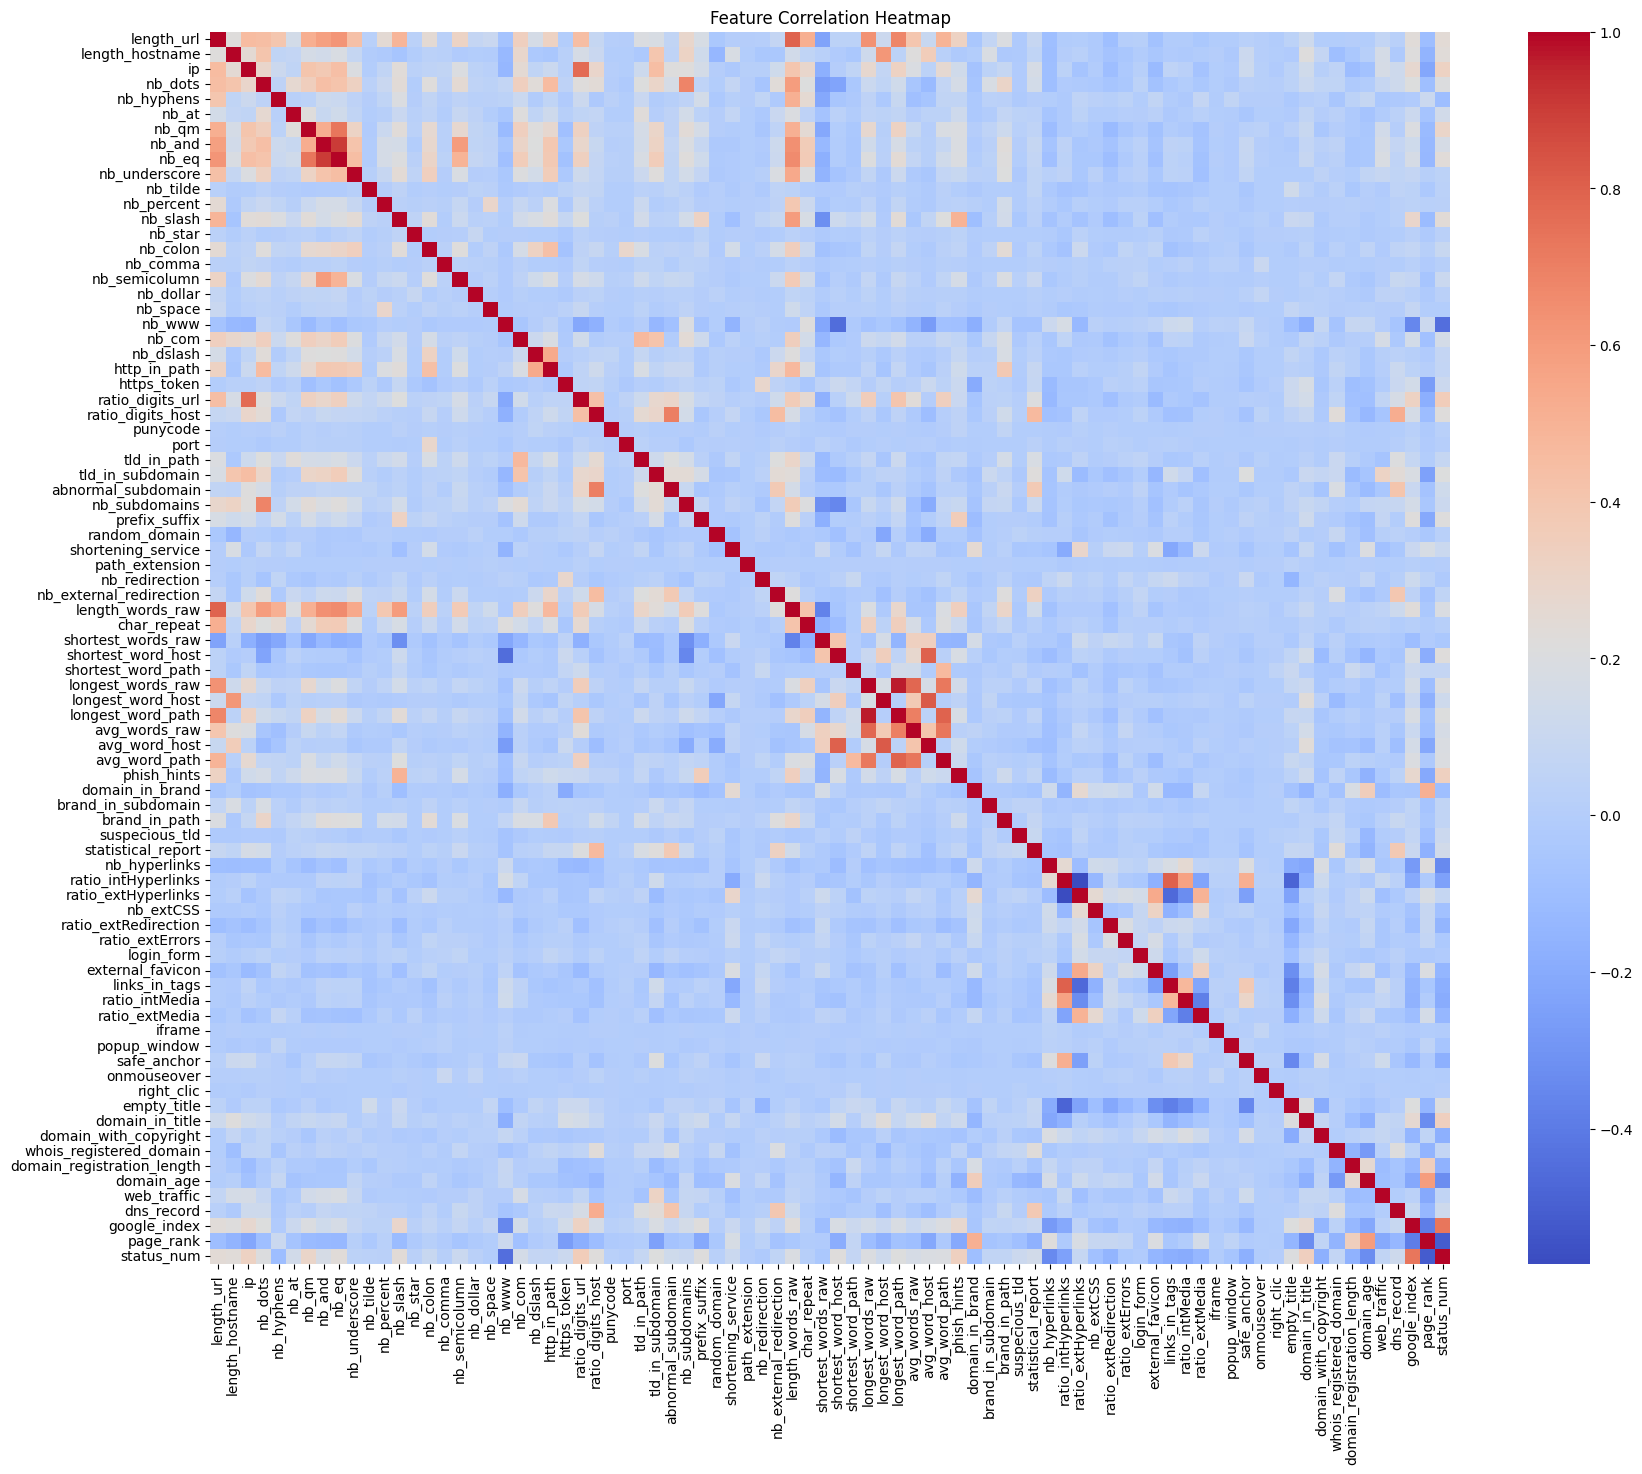

In [20]:
# convert status to numeric
df['status_num'] = df['status'].map({'legitimate': 0, 'phishing': 1})

# correlation heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [21]:
# sorted correlation with status_num
corr = df.select_dtypes(include='number').corr()
important_features = corr['status_num'][
    corr['status_num'].abs() > 0.15
].sort_values(ascending=False)

for feature, value in important_features.items():
    print(f'{feature:<30} {value:.6f}')

feature_cols = important_features.index.tolist()
feature_cols.remove('status_num')
print(f'\nTotal features for training: {len(feature_cols)}')

status_num                     1.000000
google_index                   0.731171
ratio_digits_url               0.356395
domain_in_title                0.342807
phish_hints                    0.335393
ip                             0.321698
nb_qm                          0.294319
length_url                     0.248580
nb_slash                       0.242270
length_hostname                0.238322
nb_eq                          0.233386
ratio_digits_host              0.224335
shortest_word_host             0.223084
prefix_suffix                  0.214681
longest_word_path              0.212709
tld_in_subdomain               0.208884
empty_title                    0.207043
nb_dots                        0.207029
longest_words_raw              0.200147
avg_word_path                  0.197256
avg_word_host                  0.193502
length_words_raw               0.192010
nb_and                         0.170546
avg_words_raw                  0.167564
nb_com                         0.156284


**Finding:** 35 features selected with absolute correlation > 0.15.
`google_index` is the strongest phishing indicator (0.73), phishing 
sites are rarely indexed by Google. `page_rank` is the strongest 
legitimate indicator (-0.51), legitimate sites consistently rank 
higher. `ratio_digits_url`, `phish_hints`, and `ip` are also strong 
phishing signals.

## 6. Features distributions

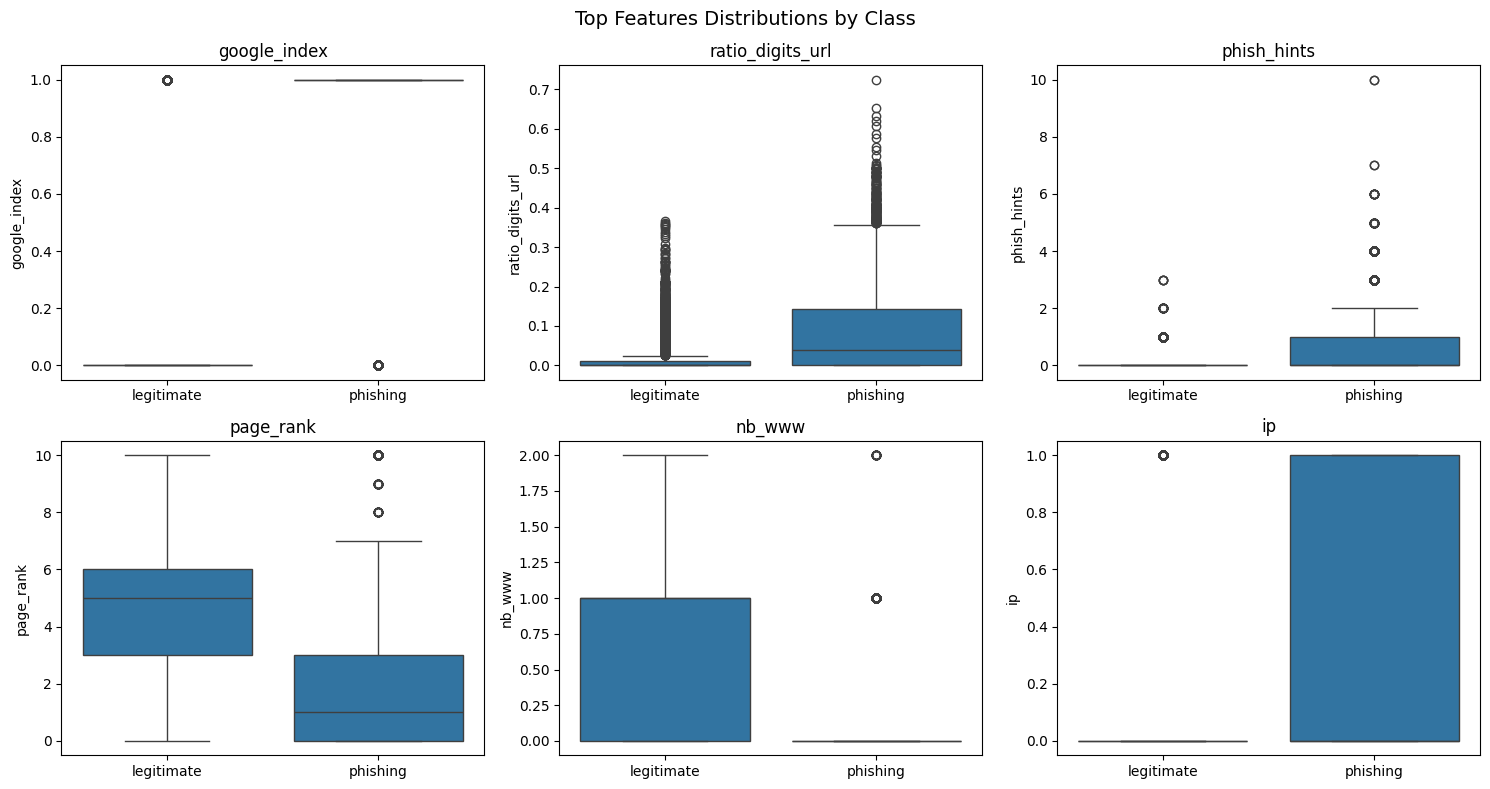

In [22]:
top_features=['google_index', 'ratio_digits_url','phish_hints', 'page_rank', 'nb_www', 'ip']

fig, axes = plt.subplots(2, 3, figsize=(15,8))

for ax, feat in zip(axes.flatten(), top_features):
    sns.boxplot(data=df, x='status', y=feat, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('')

plt.suptitle('Top Features Distributions by Class', fontsize=14)
plt.tight_layout()
plt.show()

**Finding:** The boxplots confirm the correlation analysis visually.

- `google_index` - almost all legitimate URLs score 0 (not flagged), 
  while phishing URLs also cluster near 0 but with less consistency. 
  The separation is clear.

- `ratio_digits_url` - phishing URLs have a significantly wider and 
  higher distribution of digits in the URL. Legitimate URLs are 
  tightly clustered near 0.

- `phish_hints` - phishing URLs consistently contain more suspicious 
  keywords. Legitimate URLs are almost always 0.

- `page_rank` - legitimate sites have noticeably higher page rank 
  (median ~5) compared to phishing sites (median ~1). Strong 
  separation between classes.

- `nb_www` - legitimate sites almost always have exactly 1 www. 
  Phishing sites have 0, meaning they skip the www prefix entirely.

- `ip` - Nearly all phishing URLs use a 
  raw IP address (value = 1) while legitimate URLs almost never do.

## 7. URL Length Distribution

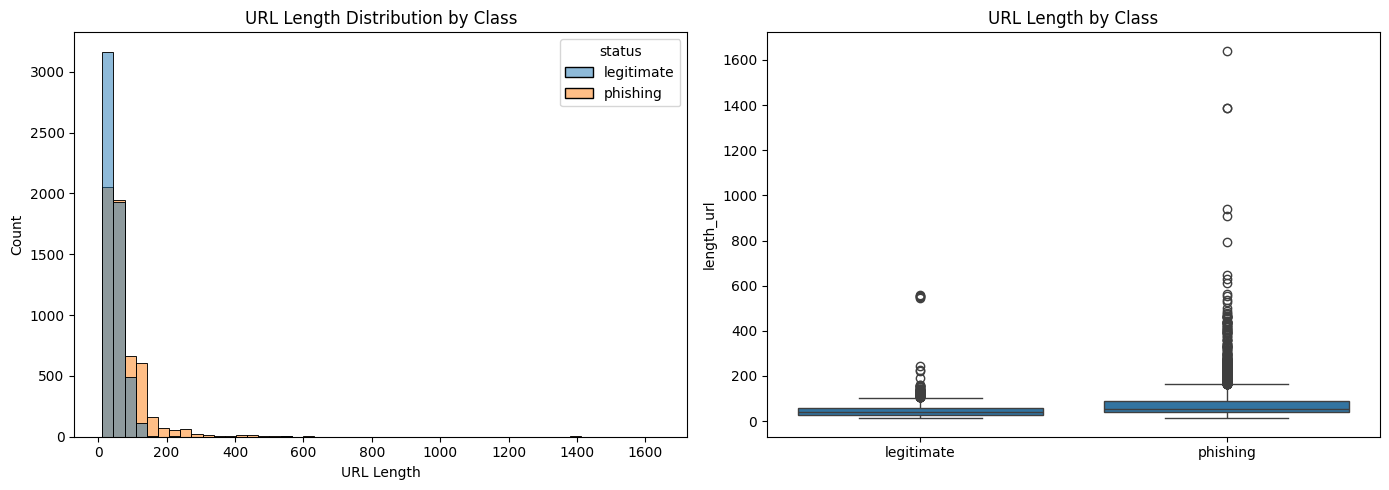

             count       mean        std   min   25%   50%   75%     max
status                                                                  
legitimate  5715.0  47.381452  27.862702  12.0  29.0  41.0  59.0   557.0
phishing    5715.0  74.871916  70.440491  15.0  38.0  55.0  88.0  1641.0


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by class
sns.histplot(data=df, x='length_url', hue='status', 
             bins=50, ax=axes[0])
axes[0].set_title('URL Length Distribution by Class')
axes[0].set_xlabel('URL Length')

# Boxplot comparison
sns.boxplot(data=df, x='status', y='length_url', ax=axes[1])
axes[1].set_title('URL Length by Class')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

# Summary stats
print(df.groupby('status')['length_url'].describe())

**Finding:** Phishing URLs are consistently longer than legitimate ones.

- Legitimate URLs have a mean length of 47 characters (median 41)
- Phishing URLs have a mean length of 75 characters (median 55)
- Phishing URLs have a much wider spread (std 70) vs legitimate (std 28),
  meaning some phishing URLs are extremely long: max 1,641 characters
- The histogram shows legitimate URLs tightly clustered under 100 
  characters, while phishing URLs spread further to the right
- The boxplot confirms phishing URLs have significantly more outliers 
  at extreme lengths. Attackers pad URLs to hide the malicious domain

`length_url` is a reliable feature for training. Phishing URLs are 
on average 58% longer than legitimate ones.

## 8. Remove Page Content Features

The Flask app will not visit URLs to scrape page content (security risk). Only features extractable from a raw URL string are kept.

In [24]:
page_content_features = [
    'google_index',          # requires Google lookup
    'page_rank',             # requires external lookup
    'domain_in_title',       # requires reading page title
    'empty_title',           # requires reading page title
    'domain_with_copyright', # requires reading page content
    'safe_anchor',           # requires reading page anchors
    'links_in_tags',         # requires reading page HTML
    'ratio_intMedia',        # requires reading page HTML
    'ratio_intHyperlinks',   # requires reading page HTML
    'nb_hyperlinks',         # requires reading page HTML
    'ratio_extRedirection'   # requires following redirects
]

url_features = [f for f in feature_cols if f not in page_content_features]
removed = [f for f in page_content_features if f in feature_cols]
print(f'Features before : {len(feature_cols)}')
print(f'Features removed: {len(removed)} -> {removed}')
print(f'Features kept   : {len(url_features)}')
print(f'\nFinal feature list:')
for f in url_features:
    print(f'  {f}')

feature_cols = url_features

Features before : 35
Features removed: 11 -> ['google_index', 'page_rank', 'domain_in_title', 'empty_title', 'domain_with_copyright', 'safe_anchor', 'links_in_tags', 'ratio_intMedia', 'ratio_intHyperlinks', 'nb_hyperlinks', 'ratio_extRedirection']
Features kept   : 24

Final feature list:
  ratio_digits_url
  phish_hints
  ip
  nb_qm
  length_url
  nb_slash
  length_hostname
  nb_eq
  ratio_digits_host
  shortest_word_host
  prefix_suffix
  longest_word_path
  tld_in_subdomain
  nb_dots
  longest_words_raw
  avg_word_path
  avg_word_host
  length_words_raw
  nb_and
  avg_words_raw
  nb_com
  domain_registration_length
  domain_age
  nb_www


**Finding:** 11 page content features removed. Final feature list contains only URL-structure features extractable without visiting the page or calling external APIs.

## 9. Save Feature List

In [25]:
import json

with open('../data/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print('Feature list saved to data/feature_cols.json')

Feature list saved to data/feature_cols.json


## Conclusion

**Dataset:** 11,430 URLs perfectly balanced (5,715 phishing, 5,715 legitimate)

**Cleaning:**
- 6 zero-variance columns dropped manually (ratio_nullHyperlinks, 
  ratio_intRedirection, ratio_intErrors, submit_email, sfh)
- 1 additional zero-variance column removed automatically (nb_or)
- Final dataset: 84 columns after cleaning

**Key findings:**

1. `google_index` is the strongest phishing indicator (0.73 correlation)
   — phishing sites are almost never indexed by Google

2. `ip` is a near-perfect binary signal — nearly all phishing URLs use 
   a raw IP address while legitimate URLs almost never do

3. `page_rank` is the strongest legitimate indicator (-0.51) — legitimate 
   sites consistently have higher page rank than phishing sites

4. Phishing URLs are 58% longer on average (mean 75 chars vs 47 chars)
   with some reaching 1,641 characters

5. `ratio_digits_url` and `phish_hints` confirm phishing URLs contain 
   more numbers and suspicious keywords like "login", "verify", "secure"

6. `nb_www` shows legitimate sites almost always use www prefix while 
   phishing sites skip it entirely

**Feature selection:**
- 35 features selected with absolute correlation > 0.15
- 11 page content features removed (app will not visit URLs)
- **Final: 24 URL-structure features for training** 

**Next step:** Train and evaluate classification models in `02_Training.ipynb`